In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [6]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1131s 7us/step


(50000, 32, 32, 3)

In [7]:
x_test.shape

(10000, 32, 32, 3)

In [8]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [9]:
y_train = y_train.reshape(-1, )
y_test = y_test.reshape(-1, )
print(y_train[:5], y_test[:5])

[6 9 9 4 1] [3 8 8 0 6]


In [10]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [11]:
def plot_sample (x, y, index):
  plt.figure(figsize=(20, 2))
  plt.imshow(x[index])
  plt.xlabel(classes[y[index]])

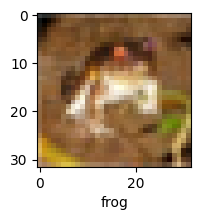

In [12]:
plot_sample(x_train, y_train, 0)

In [13]:
x_train = x_train/255.0
x_test = x_test/255.0

In [14]:
x_train

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [15]:
annmodel = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(1000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
annmodel.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
annmodel.fit(x_train, y_train, epochs = 5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.3439 - loss: 1.8392
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4171 - loss: 1.6478
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4450 - loss: 1.5674
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4664 - loss: 1.5085
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4865 - loss: 1.4588


In [18]:
cnnmodel = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
cnnmodel.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [20]:
history = cnnmodel.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=10
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.4737 - loss: 1.4657 - val_accuracy: 0.5858 - val_loss: 1.1711
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6126 - loss: 1.1081 - val_accuracy: 0.6465 - val_loss: 1.0302
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6624 - loss: 0.9697 - val_accuracy: 0.6643 - val_loss: 0.9750
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.6917 - loss: 0.8906 - val_accuracy: 0.6746 - val_loss: 0.9438
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.7151 - loss: 0.8194 - val_accuracy: 0.6855 - val_loss: 0.9305
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7345 - loss: 0.7655 - val_accuracy: 0.6913 - val_loss: 0.9186
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.7545 - loss: 0.7093 - val_accuracy: 0.6939 - val_loss: 0.9144
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.7685 -

In [21]:
cnnmodel.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7078 - loss: 0.9237


[0.9237048029899597, 0.7077999711036682]

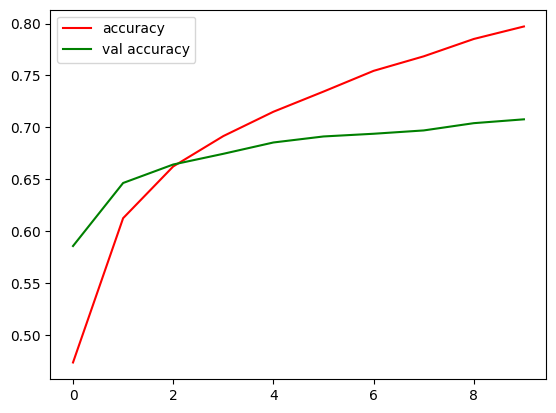

In [23]:
plt.plot(history.history['accuracy'], label='accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='val accuracy', color='green')
plt.legend()

In [25]:
y_pred = cnnmodel.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


array([[1.8158435e-03, 2.2652350e-06, 2.4018069e-03, 4.5530695e-01,
        1.1091188e-03, 5.2160567e-01, 1.5624955e-02, 9.9820736e-06,
        2.1181998e-03, 5.2429946e-06],
       [1.7826785e-03, 3.6578679e-01, 9.4945517e-06, 5.6321314e-06,
        5.3562141e-09, 3.9039357e-08, 1.9427917e-07, 2.4933640e-11,
        6.2955105e-01, 2.8641415e-03],
       [3.4902744e-02, 1.5552855e-01, 1.4170968e-02, 8.9040492e-03,
        6.5834034e-04, 3.4921335e-03, 2.7338450e-04, 2.9679793e-03,
        7.3678470e-01, 4.2317137e-02],
       [8.4963816e-01, 3.7636361e-05, 3.0112348e-02, 4.9162540e-04,
        1.6080025e-03, 2.1286730e-06, 4.8794286e-04, 5.4698000e-07,
        1.1730101e-01, 3.2062866e-04],
       [1.4421416e-08, 8.6903663e-07, 1.0323408e-03, 5.4886248e-02,
        4.7726721e-01, 2.2888482e-03, 4.6451110e-01, 7.1107780e-07,
        1.2625642e-05, 1.6623630e-08]], dtype=float32)

In [26]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(5), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [27]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

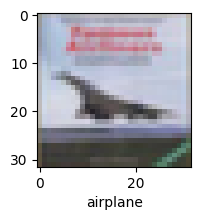

In [28]:
plot_sample(x_test, y_test, 3)

In [29]:
classes[y_classes[3]]

'airplane'

In [31]:
cnnmodel.save('cnnmodel.keras')